In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

BASE = r'C:\Users\WELCOME\Desktop\DataAnalysis_Projects\ab-testing-marketing-analysis'

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
df = pd.read_csv(BASE + r'\data\marketing_AB_clean.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (588101, 7)

Columns: ['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']

First 5 rows:


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nBasic statistics:")
df.describe()

Data types:
Unnamed: 0       int64
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

Missing values:
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Basic statistics:


,Unnamed: 0,user id,total ads,most ads hour
count,588101.0000,588101.0000,588101.0000,588101.0000
mean,294050.0000,1310692.2158,24.8209,14.4691
std,169770.2797,202225.9831,43.7152,4.8346
min,0.0000,900000.0000,1.0000,0.0000
25%,147025.0000,1143190.0000,4.0000,11.0000
50%,294050.0000,1313725.0000,13.0000,14.0000
75%,441075.0000,1484088.0000,27.0000,18.0000
max,588100.0000,1654483.0000,2065.0000,23.0000


In [4]:
print("Test groups:")
print(df['test group'].value_counts())
print(f"\nTotal users: {len(df):,}")
print(f"\nConversion rate by group:")
conversion = df.groupby('test group')['converted'].agg(['sum', 'count', 'mean'])
conversion.columns = ['Conversions', 'Total Users', 'Conversion Rate']
conversion['Conversion Rate %'] = (conversion['Conversion Rate'] * 100).round(4)
print(conversion)

Test groups:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Total users: 588,101

Conversion rate by group:
            Conversions  Total Users  Conversion Rate  Conversion Rate %
test group                                                              
ad                14423       564577           0.0255             2.5547
psa                 420        23524           0.0179             1.7854


In [5]:
# Check if groups are balanced
group_sizes = df['test group'].value_counts()
total = len(df)

print("Group size check:")
for group, size in group_sizes.items():
    print(f"  {group}: {size:,} users ({size/total*100:.2f}%)")

print(f"\nGroup size ratio: {group_sizes['ad']/group_sizes['psa']:.4f}")
print("(Ideal ratio is close to the intended split — check if imbalance is by design)")

# Check most ads hour distribution between groups
print(f"\nMost ads hour distribution by group:")
print(df.groupby('test group')['most ads hour'].describe())

Group size check:
  ad: 564,577 users (96.00%)
  psa: 23,524 users (4.00%)

Group size ratio: 24.0000
(Ideal ratio is close to the intended split — check if imbalance is by design)

Most ads hour distribution by group:
                 count    mean    std    min     25%     50%     75%     max
test group                                                                  
ad         564577.0000 14.4759 4.8418 0.0000 11.0000 14.0000 18.0000 23.0000
psa         23524.0000 14.3049 4.6562 0.0000 11.0000 14.0000 18.0000 23.0000


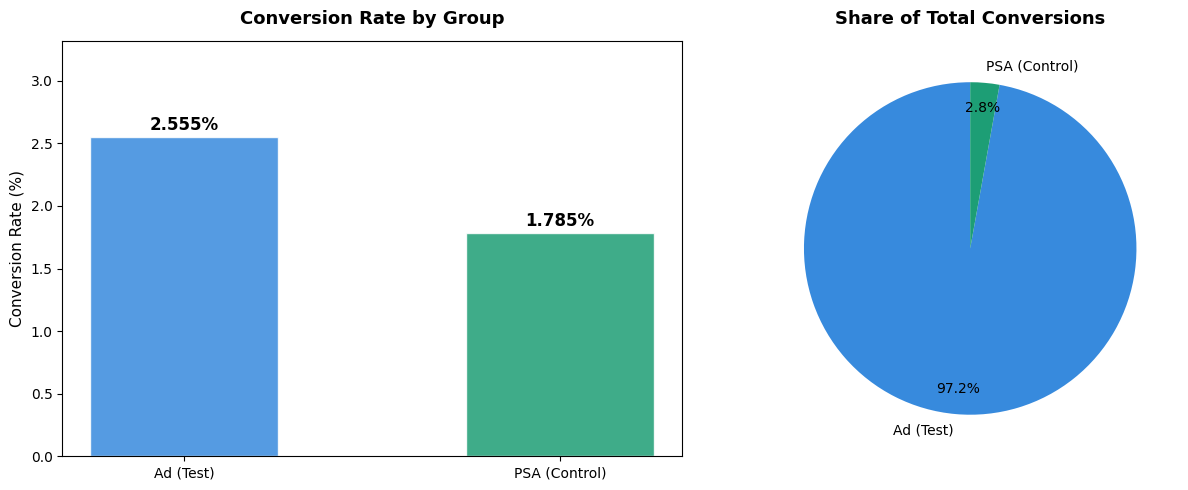

Chart saved.


In [6]:
conv_data = df.groupby('test group')['converted'].mean().reset_index()
conv_data.columns = ['Group', 'Conversion Rate']
conv_data['Conversion Rate %'] = conv_data['Conversion Rate'] * 100
conv_data['Label'] = conv_data['Group'].map({'ad': 'Ad (Test)', 'psa': 'PSA (Control)'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['#378ADD', '#1D9E75']
bars = axes[0].bar(conv_data['Label'], conv_data['Conversion Rate %'],
                   color=colors, width=0.5, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, conv_data['Conversion Rate %']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Conversion Rate by Group', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylim(0, conv_data['Conversion Rate %'].max() * 1.3)

# Pie chart of total conversions
total_conv = df.groupby('test group')['converted'].sum()
axes[1].pie(total_conv.values,
            labels=['Ad (Test)', 'PSA (Control)'],
            colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[1].set_title('Share of Total Conversions', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(BASE + r'\data\conversion_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

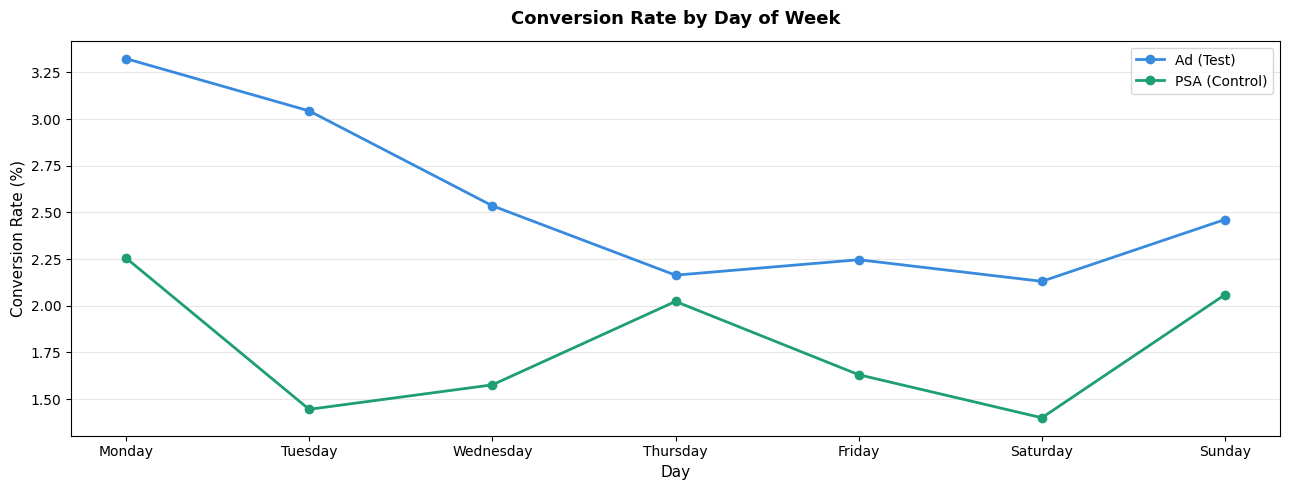

Chart saved.


In [7]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_conv = df.groupby(['most ads day', 'test group'])['converted'].mean().reset_index()
dow_conv.columns = ['Day', 'Group', 'Conversion Rate']
dow_conv['Day'] = pd.Categorical(dow_conv['Day'], categories=dow_order, ordered=True)
dow_conv = dow_conv.sort_values('Day')
dow_conv['Conversion Rate %'] = dow_conv['Conversion Rate'] * 100

fig, ax = plt.subplots(figsize=(13, 5))
for group, color, label in zip(['ad', 'psa'], ['#378ADD', '#1D9E75'], ['Ad (Test)', 'PSA (Control)']):
    data = dow_conv[dow_conv['Group'] == group]
    ax.plot(data['Day'], data['Conversion Rate %'],
            marker='o', linewidth=2, color=color, label=label, markersize=6)

ax.set_title('Conversion Rate by Day of Week', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + r'\data\conversion_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

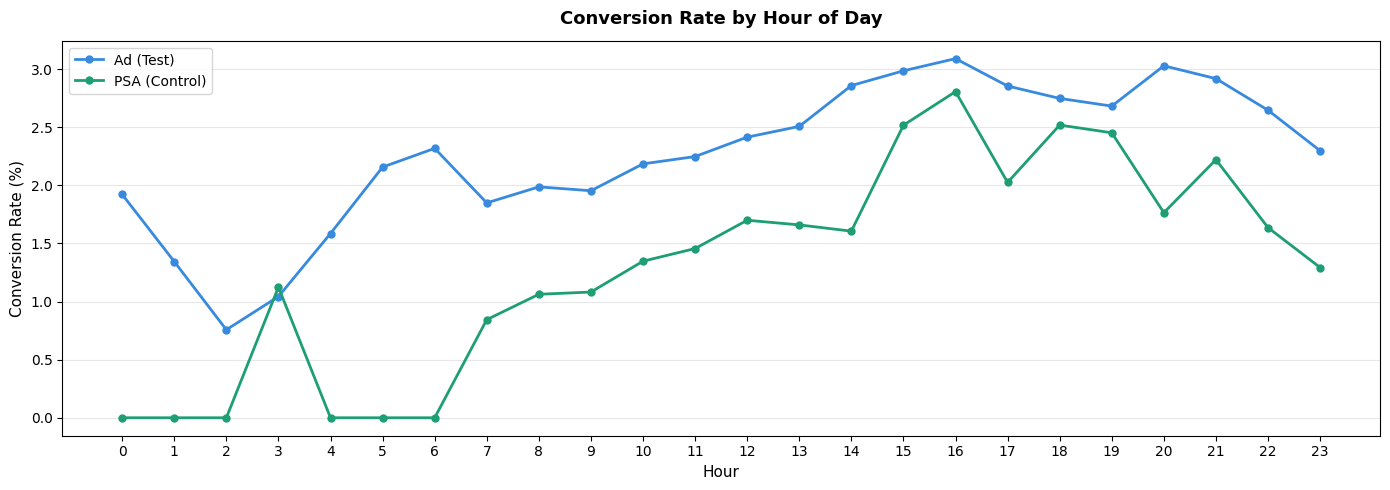

Chart saved.


In [8]:
hour_conv = df.groupby(['most ads hour', 'test group'])['converted'].mean().reset_index()
hour_conv.columns = ['Hour', 'Group', 'Conversion Rate']
hour_conv['Conversion Rate %'] = hour_conv['Conversion Rate'] * 100

fig, ax = plt.subplots(figsize=(14, 5))
for group, color, label in zip(['ad', 'psa'], ['#378ADD', '#1D9E75'], ['Ad (Test)', 'PSA (Control)']):
    data = hour_conv[hour_conv['Group'] == group]
    ax.plot(data['Hour'], data['Conversion Rate %'],
            marker='o', linewidth=2, color=color, label=label, markersize=5)

ax.set_title('Conversion Rate by Hour of Day', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hour', fontsize=11)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + r'\data\conversion_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

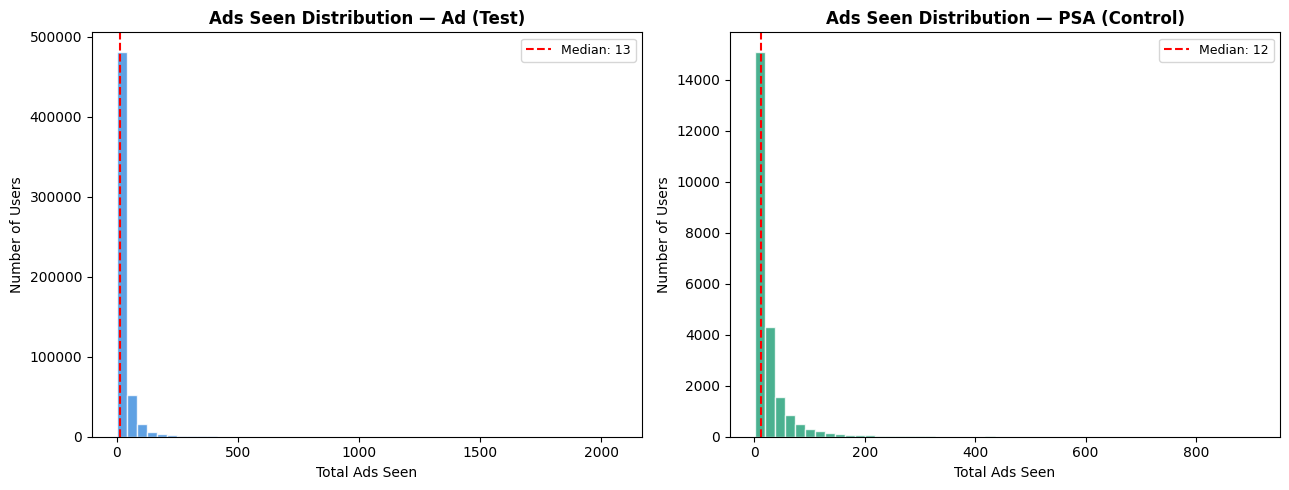

Chart saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (group, color, label) in enumerate(zip(
    ['ad', 'psa'], ['#378ADD', '#1D9E75'], ['Ad (Test)', 'PSA (Control)']
)):
    data = df[df['test group'] == group]['total ads']
    axes[i].hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'Ads Seen Distribution — {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Total Ads Seen', fontsize=10)
    axes[i].set_ylabel('Number of Users', fontsize=10)
    axes[i].axvline(data.median(), color='red', linestyle='--',
                    linewidth=1.5, label=f'Median: {data.median():.0f}')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig(BASE + r'\data\ads_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [10]:
summary = {
    'Total Users': len(df),
    'Ad Group Users': len(df[df['test group'] == 'ad']),
    'PSA Group Users': len(df[df['test group'] == 'psa']),
    'Ad Group Conversions': df[df['test group'] == 'ad']['converted'].sum(),
    'PSA Group Conversions': df[df['test group'] == 'psa']['converted'].sum(),
    'Ad Conversion Rate %': round(df[df['test group'] == 'ad']['converted'].mean() * 100, 4),
    'PSA Conversion Rate %': round(df[df['test group'] == 'psa']['converted'].mean() * 100, 4),
}

summary_df = pd.DataFrame([summary]).T.reset_index()
summary_df.columns = ['Metric', 'Value']

summary_df.to_csv(BASE + r'\data\eda_summary.csv', index=False)

print("EDA Summary:")
print(summary_df.to_string(index=False))
print("\nEDA summary saved.")

EDA Summary:
               Metric       Value
          Total Users 588101.0000
       Ad Group Users 564577.0000
      PSA Group Users  23524.0000
 Ad Group Conversions  14423.0000
PSA Group Conversions    420.0000
 Ad Conversion Rate %      2.5547
PSA Conversion Rate %      1.7854

EDA summary saved.
